In [1]:
import pandas as pd
import numpy as np 
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [2]:
X, y= load_diabetes(return_X_y= True)## we can't acces head() from here
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns= diabetes.feature_names)
y = pd.Series(diabetes.target, name = "target")
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state= 42) 
## stratify used only in classification


In [3]:
## simple model
model = LinearRegression()
model.fit(X_train, y_train)
mse = mean_squared_error(y_test, model.predict(X_test))
print("The MSE using simple Linear Regression:", mse)

The MSE using simple Linear Regression: 2821.750981001311


In [4]:
## add scaling
pipe_1 = Pipeline([
    ('sclaer', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])
pipe_1.fit(X_train, y_train)
mse_2 = mean_squared_error(y_test, pipe_1.predict(X_test))
print("The MSE after adding scaling:", mse_2)

The MSE after adding scaling: 3168.93044394734


In [5]:
## Now, we add regularization
from sklearn.linear_model import Ridge
pipe_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge( alpha=1.0))
])
pipe_2.fit(X_train, y_train)
mse_3 = mean_squared_error(y_test, pipe_2.predict(X_test))
print("The MSE using ridge:", mse_3)

The MSE using ridge: 2819.982016761734


In [6]:
## Let's try on Lasso
from sklearn.linear_model import Lasso
pipe_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha= 1.0))
])
pipe_3.fit(X_train, y_train)
mse_lasso = mean_squared_error(y_test, pipe_3.predict(X_test))
print("The mse using Lasso:", mse_lasso)


The mse using Lasso: 2784.3343859801266


In [ ]:
## OLS using statsmodel
import statsmodels.api as sm
data = pd.read_csv('MBA Salary.csv') ## uploaded on colab
data.head()


,S. No.,Percentage in Grade 10,Salary
0,1,62.00,270000
1,2,76.33,200000
2,3,72.00,240000
3,4,60.00,250000
4,5,61.00,180000


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   S. No.                  50 non-null     int64  
 1   Percentage in Grade 10  50 non-null     float64
 2   Salary                  50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


In [24]:
## train_test_split

X = data.drop(['Salary','S. No.'], axis= 1)
X = sm.add_constant(X)  ##bias term
y = data['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3)

In [25]:
## fit the model 
model_mba = sm.OLS(y_train, X_train).fit()
model_mba.params

,0
const,63337.706047
Percentage in Grade 10,3110.282650


In [26]:
model_mba.summary2() ## this is the speciality of statsmodel

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Ordinary least squares
==================================================================================
Model:                   OLS                   Adj. R-squared:          0.138     
Dependent Variable:      Salary                AIC:                     884.6105  
Date:                    2026-05-03 08:26      BIC:                     887.7212  
No. Observations:        35                    Log-Likelihood:          -440.31   
Df Model:                1                     F-statistic:             6.434     
Df Residuals:            33                    Prob (F-statistic):      0.0161    
R-squared:               0.163                 Scale:                   5.2488e+09
----------------------------------------------------------------------------------
                         Coef.     Std.Err.    t    P>|t|     [0.025      0.975]  
----------------------------------------------------------------------------------
const                  63337.7060 78477.7493 0.8071 0.4254 -96326.4754 223001.8875
Percentage in Grade 10  3110.2826  1226.1982 2.5365 0.0161    615.5637   5605.0016
----------------------------------------------------------------------------------
Omnibus:                     1.222             Durbin-Watson:                1.799
Prob(Omnibus):               0.543             Jarque-Bera (JB):             1.141
Skew:                        0.293             Prob(JB):                     0.565
Kurtosis:                    2.338             Condition No.:                410  
==================================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

<Figure size 800x600 with 0 Axes>

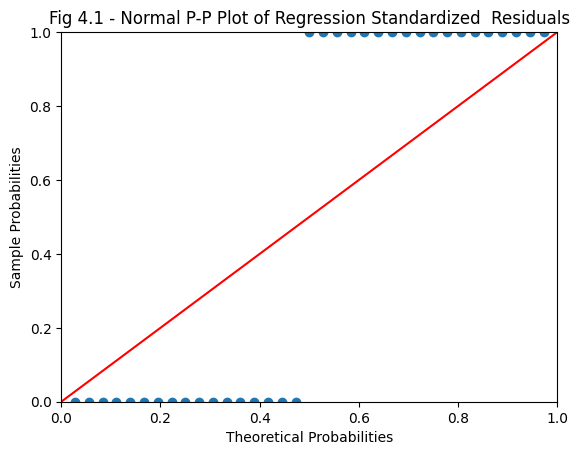

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
mba_salary_resid = model_mba.resid  
probplot = sm.ProbPlot(mba_salary_resid)  
plt.figure( figsize = (8, 6)) 
probplot.ppplot( line='45' )
plt.title ( "Fig 4.1 - Normal P-P Plot of Regression Standardized  Residuals" )
plt.show()

In [31]:
y_pred = model_mba.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
np.abs(r2_score(y_test, y_pred))
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(68742.25707422463)

## GRADIENT

In [20]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
data = load_diabetes(as_frame= True)
df = data.frame
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

Learned slope: 47.497497006104325
Learned intercept: 152.00335418018744


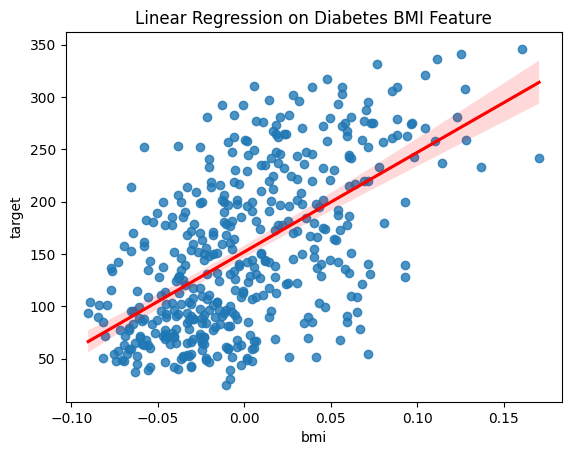

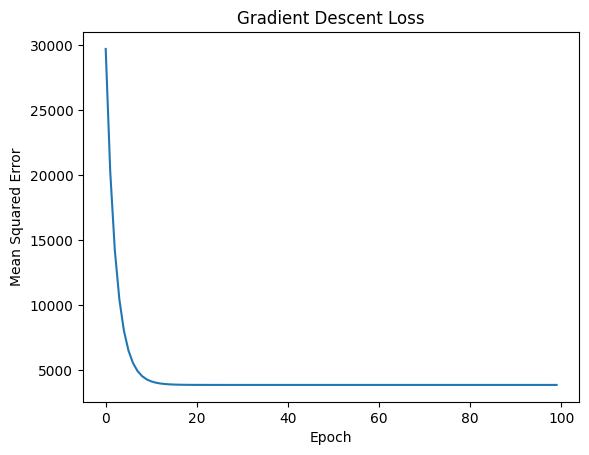

In [ ]:
X = df[["bmi"]].values
y = df["target"].values.reshape(-1, 1)

# Scale feature for smoother gradient descent
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Parameters
m = 0.0
b = 0.0
learning_rate = 0.1
epochs = 100

n = len(X_train)
loss_history = []

# Gradient descent
for epoch in range(epochs):
    y_pred = m * X_train + b

    error = y_pred - y_train
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients
    dm = (2 / n) * np.sum(error * X_train)
    db = (2 / n) * np.sum(error)

    # Update parameters
    m -= learning_rate * dm
    b -= learning_rate * db

print("Learned slope:", m)
print("Learned intercept:", b)

# Convert scaled BMI back only for nicer graph labels
df_plot = df[["bmi", "target"]].copy()

# Simple built-in-style visualization using seaborn
sns.regplot(data=df_plot, x="bmi", y="target", line_kws={"color": "red"})
plt.title("Linear Regression on Diabetes BMI Feature")
plt.show()

# Loss curve
sns.lineplot(x=range(epochs), y=loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Loss")
plt.show()

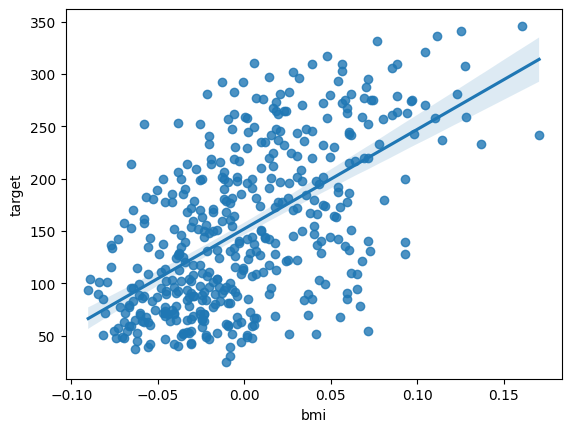

In [17]:
## one-liner using seaborn
sns.regplot(data = df_plot, x= 'bmi', y = 'target')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


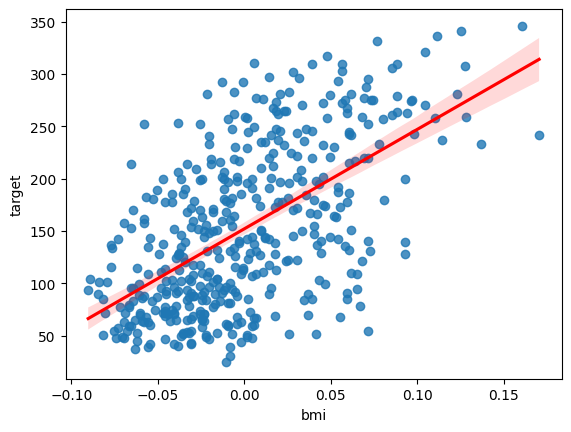

In [36]:
## using in-built SGDregressor
Pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',SGDRegressor(
        loss = 'squared_error',
        learning_rate= 'constant',
        eta0= 0.01,
        max_iter= 1000,
        random_state= 42
    ) )
])

model = Pipe.fit(X_train, y_train)

y_pred = model.predict(X_test)


sns.regplot(data = df,x = 'bmi', y = 'target', line_kws= {'color': 'red'})
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, r2_score as sklearn_r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = sklearn_r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 score:", r2)


MSE: 4101.592276973193
R2 score: 0.2258446961015086


## From scratch

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes


In [5]:
## load dataset

data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y,train_size= 0.7, random_state= 42)

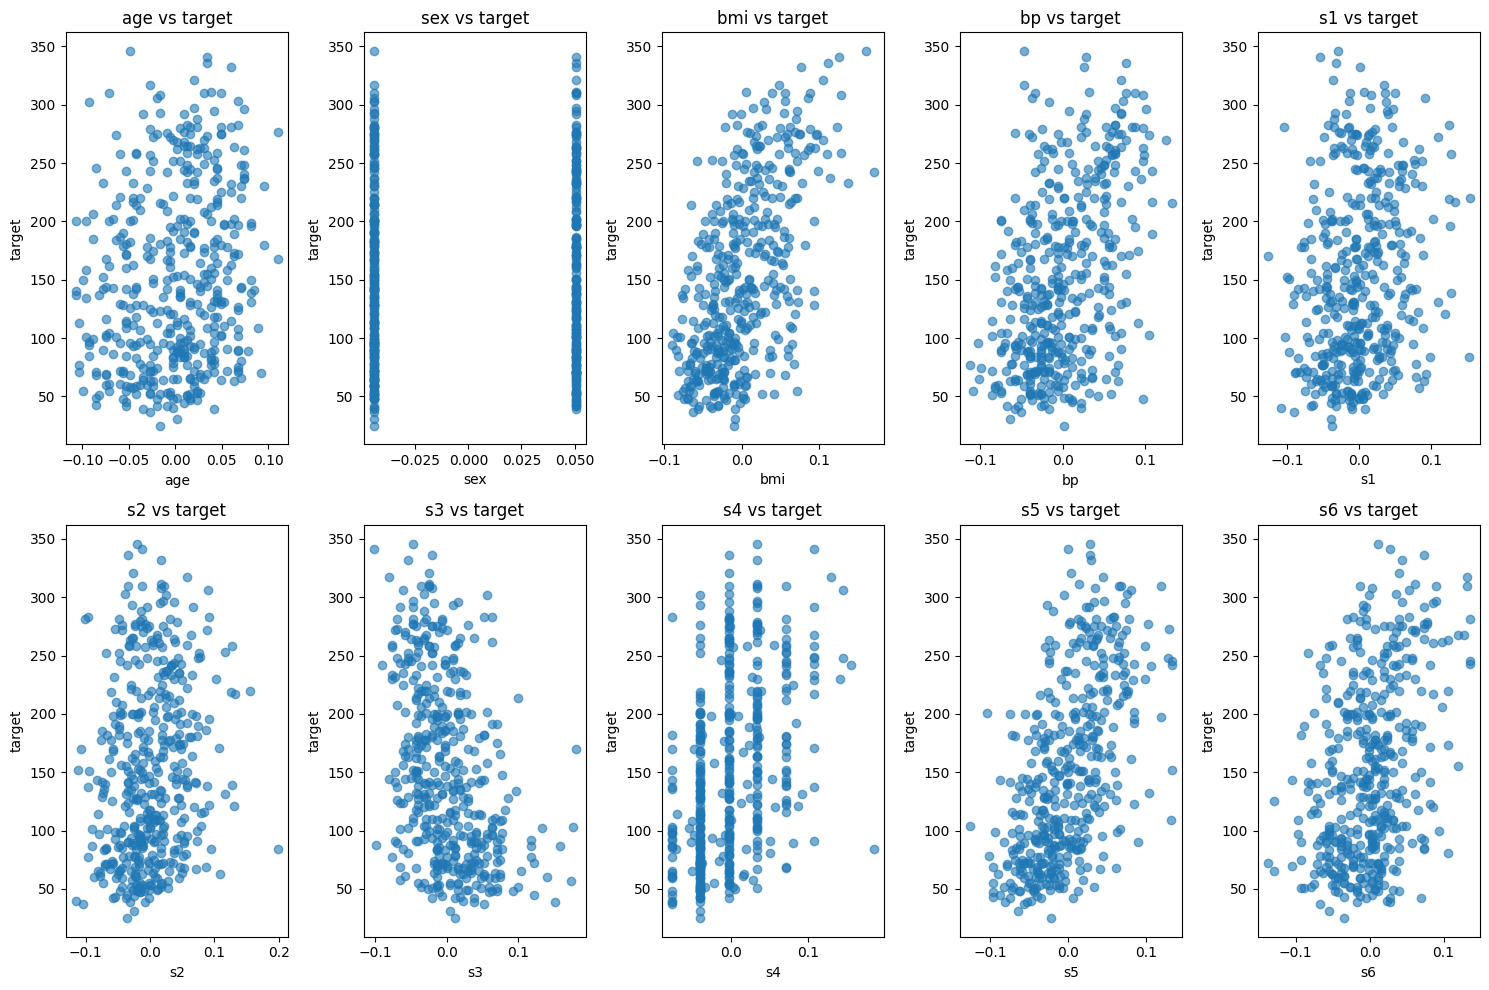

In [30]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
plt.figure(figsize=(15, 10))

for i, feature in enumerate(data.feature_names):
    plt.subplot(2, 5, i + 1)
    plt.scatter(df[feature], df["target"], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("target")
    plt.title(f"{feature} vs target")

plt.tight_layout()
plt.show()


In [ ]:
class linearRegression:
    def __init__(self, method = 'ols', learning_rate = 0.01, epochs =1000):
        self.method = method
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    def add_bias(self,X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def fit_ols(self, X_b, y):
        return np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    
    def stochastic_gradient(self, X_b, y):
        m , n = X_b.shape
        weights = np.zeros(n)
        for _ in range(self.epochs):
            for i in range(m):
                random_index = np.random.randint(m)
                x_i = X_b[random_index]
                yi = y[random_index]
                
                y_pred = x_i @ weights
                error = y_pred - yi
                gradient = 2 * error * x_i
                
                weights -= self.learning_rate * gradient
        return weights
    
    def fit(self, X, y):
        X_b = self.add_bias(X)
        
        if self.method == 'ols':
            self.weights = self.fit_ols(X_b, y)
            
        if self.method == 'stochastic_gradient':
            self.weights = self.stochastic_gradient(X_b, y)
    
    def predict(self, X):
        X_b = self.add_bias(X)
        return X_b @ self.weights
    
    def evaluate(self, X, y):
        y_pred = self.predict(X)
        
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        return mse, r2

In [20]:
ols = linearRegression()
ols.fit(X_train,y_train)
mse, r2 = ols.evaluate(X_test, y_test)

print("MSE:", mse)
print("r2_score:", r2)

MSE: 2821.7509810013094
r2_score: 0.47728971643226203


In [25]:
sgd_model = linearRegression(
    method="stochastic_gradient",
    learning_rate=0.01,
    epochs=1000
)
sgd_model.fit(X_train, y_train)
mse, r2 = sgd_model.evaluate(X_test, y_test)

print("MSE using stochastic:", mse)
print("R2_score using stochastic:", r2)



MSE using stochastic: 2839.951585906241
R2_score using stochastic: 0.47391817747825227


ValueError: x and y must be the same size

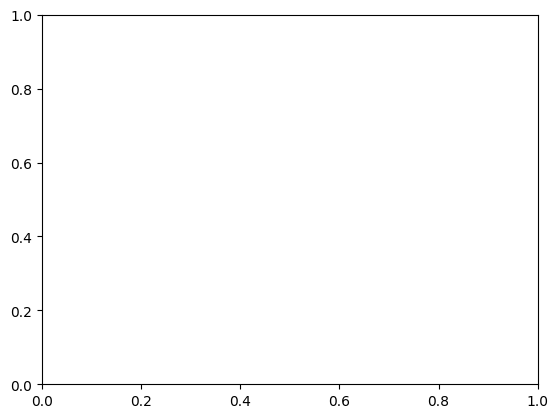